In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(24)
np.random.seed(24)

---
## Markov Decision Process (MDP) Framework

In [2]:
class GridWorld:
    """
    A simple 4x4 GridWorld MDP.
    State: (row, col). Goal: reach (3,3). Pit: (2,2).
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.goal = (size-1, size-1)
        self.pit = (size//2, size//2)
        self.action_effects = [(-1,0),(1,0),(0,-1),(0,1)]  # U D L R

    def state_id(self, s): return s[0]*self.size + s[1]
    def state_xy(self, sid): return (sid // self.size, sid % self.size)

    def reset(self):
        self.pos = (0, 0)
        return self.state_id(self.pos)

    def step(self, action):
        dr, dc = self.action_effects[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)
        done = False
        if self.pos == self.goal:
            reward, done = +10.0, True
        elif self.pos == self.pit:
            reward, done = -10.0, True
        else:
            reward = -0.1  # small step penalty encourages efficiency
        return self.state_id(self.pos), reward, done

env = GridWorld()
print(f"GridWorld: {env.n_states} states, {env.n_actions} actions")
print(f"Goal state id: {env.state_id(env.goal)}, Pit state id: {env.state_id(env.pit)}")

GridWorld: 16 states, 4 actions
Goal state id: 15, Pit state id: 10


## Softmax Policy

In [3]:
class SoftmaxPolicy:
    """
    Tabular softmax policy: pi(a|s; theta) = exp(theta[s,a]) / sum_a' exp(theta[s,a'])
    This parametrizes pi differentiably, as required by the policy gradient theorem.
    """
    def __init__(self, n_states, n_actions, temperature=1.0):
        self.theta = np.zeros((n_states, n_actions))
        self.tau = temperature

    def probs(self, s):
        logits = self.theta[s] / self.tau
        logits -= logits.max()   # numerical stability
        exp_l = np.exp(logits)
        return exp_l / exp_l.sum()

    def select_action(self, s):
        return np.random.choice(len(self.theta[s]), p=self.probs(s))

    def log_grad(self, s, a):
        """Gradient of log pi(a|s) w.r.t. theta[s,:] (one-hot minus probs)."""
        p = self.probs(s)
        grad = -p.copy()
        grad[a] += 1.0
        return grad

---
## Actor-Critic

The Actor-Critic method maintains two networks:
- **Critic**: estimates $Q(s,a;w) = \phi(s,a)^\top w$ using TD(0)
- **Actor**: updates policy parameter $\theta$ using the critic's estimate

$$w^{(n+1)} \leftarrow w^{(n)} + \beta_w \, \delta \, \phi(s,a)$$
$$\theta^{(n+1)} \leftarrow \theta^{(n)} + \beta_\theta \, Q(s,a;w^{(n)}) \, \nabla_\theta \ln \pi(s,a;\theta^{(n)})$$

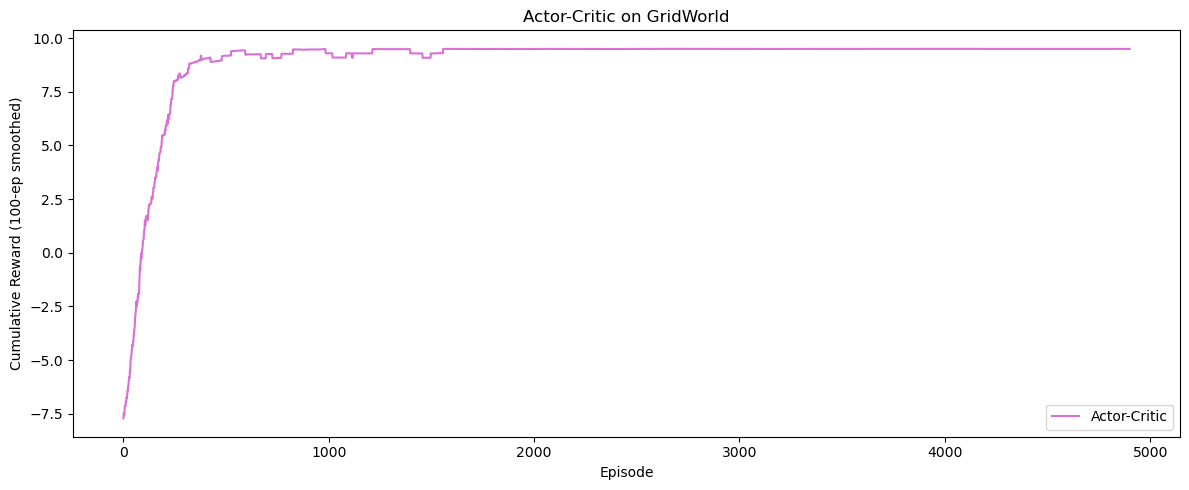

Final smoothed reward: 9.496


In [ ]:
def actor_critic(env, num_episodes=5000, gamma=0.99, lr_actor=0.01, lr_critic=0.05):
    """
    Algorithm 5 (paper): Actor-Critic.
    Critic: linear function approximation Q(s,a;w) = phi(s,a)^T w
    Actor: softmax policy parametrized by theta
    Single-scale setting: actor and critic update simultaneously.
    """
    n_s, n_a = env.n_states, env.n_actions
    # Feature vector: one-hot encoding of (state, action) pair
    n_features = n_s * n_a

    def phi(s, a):
        """State-action feature vector (one-hot)."""
        feat = np.zeros(n_features)
        feat[s * n_a + a] = 1.0
        return feat

    w = np.zeros(n_features)  # Critic parameters
    policy = SoftmaxPolicy(n_s, n_a) # Actor parameters (theta)
    cum_rewards = []

    for ep in range(num_episodes):
        s = env.reset()
        a = policy.select_action(s)
        done = False
        total_r = 0

        while not done:
            s_next, r, done = env.step(a)
            total_r += r
            a_next = policy.select_action(s_next)

            # Critic update: TD error
            Q_sa = phi(s, a).dot(w)
            Q_next = phi(s_next, a_next).dot(w) * (1 - done)
            delta = r + gamma * Q_next - Q_sa   # TD error
            w += lr_critic * delta * phi(s, a)  # w^(n+1) (line 9)

            # Actor update: policy gradient (line 10)
            policy.theta[s] += lr_actor * Q_sa * policy.log_grad(s, a)

            s, a = s_next, a_next

        cum_rewards.append(total_r)

    return policy, w, cum_rewards


policy_ac, w_ac, rewards_ac = actor_critic(env, num_episodes=5000)


window = 100
smooth = np.convolve(rewards_ac, np.ones(window)/window, mode='valid')
plt.figure(figsize=(12, 5))
plt.plot(smooth, label='Actor-Critic', linewidth=1.5, color='orchid')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward (100-ep smoothed)')
plt.title('Actor-Critic on GridWorld')
plt.legend()
plt.tight_layout()
plt.show()

smooth_ac = np.convolve(rewards_ac, np.ones(window)/window, mode='valid')
print(f"Final smoothed reward: {smooth_ac[-1]:.3f}")
